In [4]:
import pandas as pd

transactions = pd.read_excel('Data/QVI_transaction_data.xlsx') 
customers = pd.read_csv('Data/QVI_purchase_behaviour.csv')
transactions['DATE'] = pd.to_datetime(transactions['DATE'], unit='D', origin='1899-12-30')

print("Data after fixing dates:")
display(transactions.head())

print("\n--- Summary Statistics ---")
display(transactions.describe())

Data after fixing dates:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8



--- Summary Statistics ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [5]:
outliers = transactions[transactions['PROD_QTY'] == 200]
print("The Outlier Transactions:")
display(outliers)

if not outliers.empty:
    suspicious_customer = outliers['LYLTY_CARD_NBR'].iloc[0]
    customer_history = transactions[transactions['LYLTY_CARD_NBR'] == suspicious_customer]
    print(f"\nPurchase History for Customer {suspicious_customer}:")
    display(customer_history)

The Outlier Transactions:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0



Purchase History for Customer 226000:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [6]:
transactions = transactions[transactions['LYLTY_CARD_NBR'] != 226000]

customers = customers[customers['LYLTY_CARD_NBR'] != 226000]

print("--- Data after dropping the outlier ---")
display(transactions.describe())

--- Data after dropping the outlier ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264834,264834.000000,2.648340e+05,2.648340e+05,264834.000000,264834.000000,264834.000000
mean,2018-12-30 00:52:10.292938240,135.079423,1.355488e+05,1.351576e+05,56.583554,1.905813,7.299346
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760050e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351365e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.026998e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.784063,8.057990e+04,7.813292e+04,32.826444,0.343436,2.527241


In [7]:
import re

transactions['PACK_SIZE'] = transactions['PROD_NAME'].str.extract('(\d+)').astype(float)

transactions['BRAND'] = transactions['PROD_NAME'].str.split().str[0]

print("New columns created: PACK_SIZE and BRAND")
display(transactions[['PROD_NAME', 'PACK_SIZE', 'BRAND']].head())

print("\nUnique Packet Sizes:")
print(sorted(transactions['PACK_SIZE'].unique()))

New columns created: PACK_SIZE and BRAND


,PROD_NAME,PACK_SIZE,BRAND
0,Natural Chip Compny SeaSalt175g,175.0,Natural
1,CCs Nacho Cheese 175g,175.0,CCs
2,Smiths Crinkle Cut Chips Chicken 170g,170.0,Smiths
3,Smiths Chip Thinly S/Cream&Onion 175g,175.0,Smiths
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150.0,Kettle



Unique Packet Sizes:
[np.float64(70.0), np.float64(90.0), np.float64(110.0), np.float64(125.0), np.float64(134.0), np.float64(135.0), np.float64(150.0), np.float64(160.0), np.float64(165.0), np.float64(170.0), np.float64(175.0), np.float64(180.0), np.float64(190.0), np.float64(200.0), np.float64(210.0), np.float64(220.0), np.float64(250.0), np.float64(270.0), np.float64(300.0), np.float64(330.0), np.float64(380.0)]


In [9]:
print("Brands before cleaning:")
print(transactions['BRAND'].unique())

brand_map = {
    'RED': 'Red Rock Deli',
    'RRD': 'Red Rock Deli',
    'Smith': 'Smiths',
    'Dorito': 'Doritos',
    'GrnWves': 'Grain Waves',
    'Grain': 'Grain Waves',
    'Infzns': 'Infuzions',
    'WW': 'Woolworths',
    'NCC': 'Natural Chip Co',
    'Snbts': 'Sunbites',
    'Red': 'Red Rock Deli',
    'Natural': 'Natural Chip Co'
}

transactions['BRAND'] = transactions['BRAND'].replace(brand_map)

print("\nBrands after cleaning:")
print(transactions['BRAND'].unique())

Brands before cleaning:
['Natural' 'CCs' 'Smiths' 'Kettle' 'Old' 'Grain Waves' 'Doritos'
 'Twisties' 'Woolworths' 'Thins' 'Burger' 'Natural Chip Co' 'Cheezels'
 'Infuzions' 'Red' 'Pringles' 'Tyrrells' 'Cobs' 'French' 'Red Rock Deli'
 'Tostitos' 'Cheetos' 'Sunbites']

Brands after cleaning:
['Natural Chip Co' 'CCs' 'Smiths' 'Kettle' 'Old' 'Grain Waves' 'Doritos'
 'Twisties' 'Woolworths' 'Thins' 'Burger' 'Cheezels' 'Infuzions'
 'Red Rock Deli' 'Pringles' 'Tyrrells' 'Cobs' 'French' 'Tostitos'
 'Cheetos' 'Sunbites']


In [10]:
data = pd.merge(transactions, customers, on='LYLTY_CARD_NBR', how='left')

print("Checking for nulls after merge:")
print(data.isnull().sum())

print("\nFinal Merged Data Peek:")
display(data.head())

Checking for nulls after merge:
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Final Merged Data Peek:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


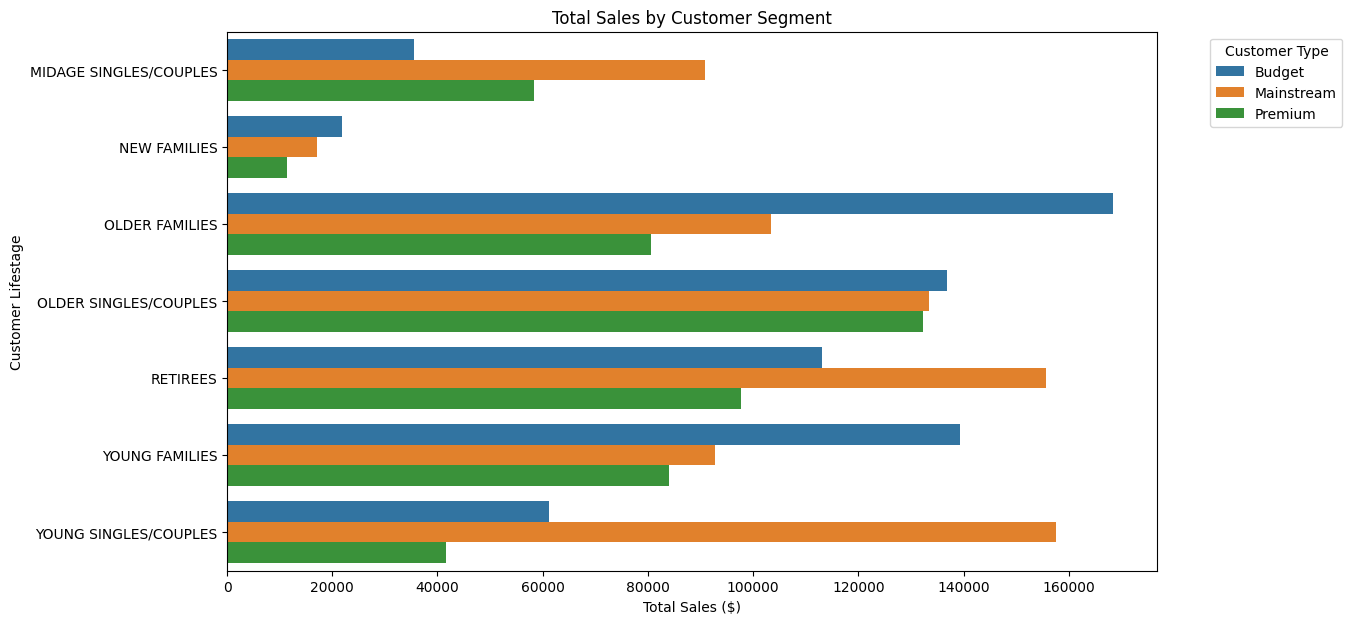

Top Spending Segments:


,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,168363.25
19,YOUNG SINGLES/COUPLES,Mainstream,157621.60
13,RETIREES,Mainstream,155677.05
15,YOUNG FAMILIES,Budget,139345.85
9,OLDER SINGLES/COUPLES,Budget,136769.80
10,OLDER SINGLES/COUPLES,Mainstream,133393.80
11,OLDER SINGLES/COUPLES,Premium,132263.15
12,RETIREES,Budget,113147.80
7,OLDER FAMILIES,Mainstream,103445.55
14,RETIREES,Premium,97646.05


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sales_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(data=sales_summary, y='LIFESTAGE', x='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Lifestage')
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Top Spending Segments:")
display(sales_summary.sort_values(by='TOT_SALES', ascending=False).head(10))

In [12]:
customers_count = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()

units_per_customer = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index()
units_per_customer['AVG_UNITS_PER_CUST'] = units_per_customer['PROD_QTY'] / customers_count['LYLTY_CARD_NBR']

print("Average Units per Customer (Who eats more chips?):")
display(units_per_customer.sort_values(by='AVG_UNITS_PER_CUST', ascending=False).head(10))

Average Units per Customer (Who eats more chips?):


,LIFESTAGE,PREMIUM_CUSTOMER,PROD_QTY,AVG_UNITS_PER_CUST
7,OLDER FAMILIES,Mainstream,27756,9.804309
6,OLDER FAMILIES,Budget,45065,9.639572
8,OLDER FAMILIES,Premium,21771,9.578091
15,YOUNG FAMILIES,Budget,37111,9.238486
17,YOUNG FAMILIES,Premium,22406,9.209207
16,YOUNG FAMILIES,Mainstream,25044,9.180352
11,OLDER SINGLES/COUPLES,Premium,33986,7.154947
9,OLDER SINGLES/COUPLES,Budget,35220,7.145466
10,OLDER SINGLES/COUPLES,Mainstream,34997,7.098783
1,MIDAGE SINGLES/COUPLES,Mainstream,22699,6.796108


C:\Users\asus\AppData\Local\Temp\ipykernel_14176\4208379508.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  price_per_unit = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(lambda x: x['TOT_SALES'].sum() / x['PROD_QTY'].sum()).reset_index()


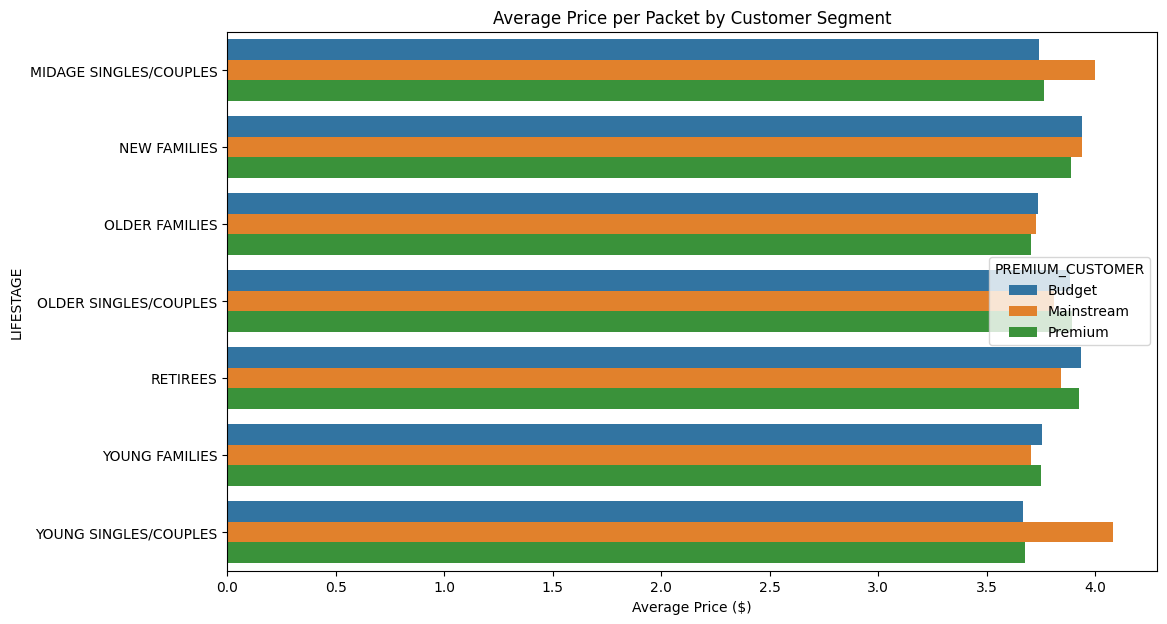

,LIFESTAGE,PREMIUM_CUSTOMER,AVG_PRICE_PER_UNIT
19,YOUNG SINGLES/COUPLES,Mainstream,4.080079
1,MIDAGE SINGLES/COUPLES,Mainstream,4.000346
4,NEW FAMILIES,Mainstream,3.939315
3,NEW FAMILIES,Budget,3.936178
12,RETIREES,Budget,3.933660
14,RETIREES,Premium,3.924050
11,OLDER SINGLES/COUPLES,Premium,3.891695
5,NEW FAMILIES,Premium,3.886067
9,OLDER SINGLES/COUPLES,Budget,3.883299
13,RETIREES,Mainstream,3.842170


In [13]:
price_per_unit = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).apply(lambda x: x['TOT_SALES'].sum() / x['PROD_QTY'].sum()).reset_index()
price_per_unit.columns = ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_PRICE_PER_UNIT']

plt.figure(figsize=(12, 7))
sns.barplot(data=price_per_unit, y='LIFESTAGE', x='AVG_PRICE_PER_UNIT', hue='PREMIUM_CUSTOMER')
plt.title('Average Price per Packet by Customer Segment')
plt.xlabel('Average Price ($)')
plt.show()

display(price_per_unit.sort_values(by='AVG_PRICE_PER_UNIT', ascending=False))